In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from src.data_preprocessing import *
from scipy.stats import chi2_contingency
import src.data_preprocessing as dp

In [3]:
df = load_dataset('../../data/processed/cardio_train.csv', sep=',')
print(type(df))
df.head()

<class 'pandas.DataFrame'>


,age,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,gender_male,BMI
0,50,168,62.0,110,80,1,1,0,0,1,0,0,21.967120
1,55,156,85.0,140,90,3,1,0,0,1,1,1,34.927679
2,51,165,64.0,130,70,3,1,0,0,0,1,1,23.507805
3,48,169,82.0,150,100,1,1,0,0,1,1,0,28.710479
4,47,156,56.0,100,60,1,1,0,0,0,0,1,23.011177


In [4]:
df.describe()

,age,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,gender_male,BMI
count,68606.000000,68606.000000,68606.000000,68606.000000,68606.00000,68606.000000,68606.000000,68606.000000,68606.000000,68606.000000,68606.000000,68606.000000,68606.000000
mean,52.828514,164.409454,74.086303,126.671005,81.30576,1.364793,1.225811,0.087966,0.053334,0.803326,0.494723,0.651313,27.448172
std,6.768806,7.941311,14.212777,16.688603,9.45360,0.678996,0.571659,0.283248,0.224699,0.397486,0.499976,0.476558,5.211817
min,29.000000,100.000000,28.000000,60.000000,40.00000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.726644
25%,48.000000,159.000000,65.000000,120.000000,80.00000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,23.875115
50%,53.000000,165.000000,72.000000,120.000000,80.00000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,26.346494
75%,58.000000,170.000000,82.000000,140.000000,90.00000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,30.116213
max,64.000000,250.000000,200.000000,240.000000,182.00000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,60.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 68606 entries, 0 to 68605
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          68606 non-null  int64  
 1   height       68606 non-null  int64  
 2   weight       68606 non-null  float64
 3   ap_hi        68606 non-null  int64  
 4   ap_lo        68606 non-null  int64  
 5   cholesterol  68606 non-null  int64  
 6   gluc         68606 non-null  int64  
 7   smoke        68606 non-null  int64  
 8   alco         68606 non-null  int64  
 9   active       68606 non-null  int64  
 10  cardio       68606 non-null  int64  
 11  gender_male  68606 non-null  int64  
 12  BMI          68606 non-null  float64
dtypes: float64(2), int64(11)
memory usage: 6.8 MB


In [6]:
df.shape

(68606, 13)

Text(0.5, 1.0, 'Cas cardiaques')

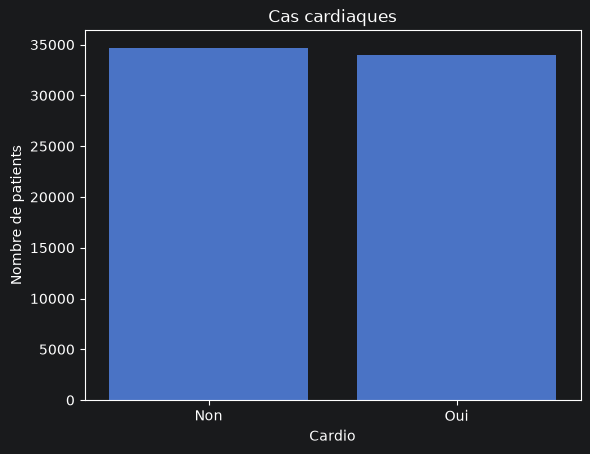

In [7]:
sns.countplot(data=df, x="cardio")
plt.xticks([0, 1], ["Non", "Oui"])
plt.ylabel("Nombre de patients")
plt.xlabel("Cardio")
plt.title("Cas cardiaques")

Text(0.5, 1.0, 'Cas cardiaques par genre')

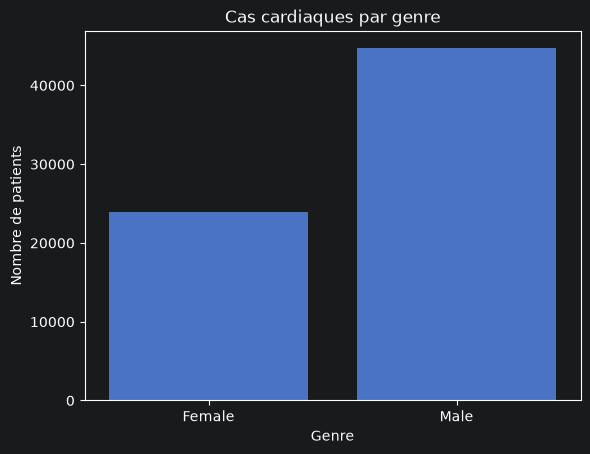

In [8]:
sns.countplot(data=df, x="gender_male")
plt.xticks([0, 1], ["Female", "Male"])
plt.ylabel("Nombre de patients")
plt.xlabel("Genre")
plt.title("Cas cardiaques par genre")

  gender_label     cardio
0        Femme  49.970738
1        Homme  49.205532


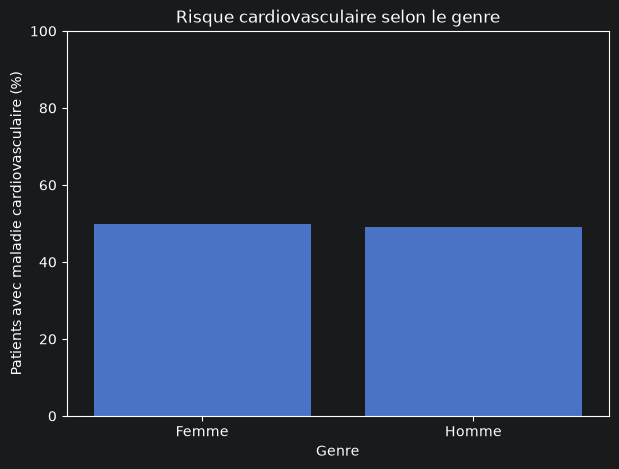

Table de contingence :
cardio            0      1
gender_label              
Femme         11968  11954
Homme         22697  21987

Chi² : 3.6191
p-value : 0.05712


In [9]:
df["gender_label"] = df["gender_male"].map({
    0: "Femme",
    1: "Homme"
})

# 2. Calculer le pourcentage de cardio = 1 par genre
risk_by_gender = (
    df
    .groupby("gender_label")["cardio"]
    .mean()
    .mul(100)
    .reset_index()
)

print(risk_by_gender)

# 3. Graphique en pourcentage
plt.figure(figsize=(7, 5))

sns.barplot(
    data=risk_by_gender,
    x="gender_label",
    y="cardio"
)

plt.title("Risque cardiovasculaire selon le genre")
plt.xlabel("Genre")
plt.ylabel("Patients avec maladie cardiovasculaire (%)")
plt.ylim(0, 100)
plt.show()

table = pd.crosstab(df["gender_label"], df["cardio"])

chi2, p_value, dof, expected = chi2_contingency(table)

print("Table de contingence :")
print(table)

print(f"\nChi² : {chi2:.4f}")
print(f"p-value : {p_value:.5f}")

Text(0.5, 1.0, 'Répartition des patients par age et genre')

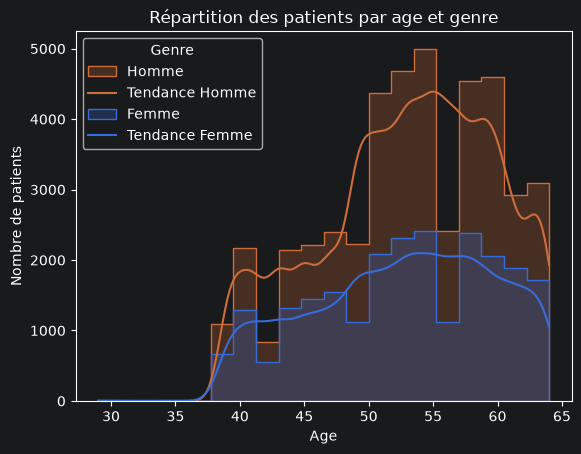

In [10]:
sns.histplot(
    data=df,
    x="age",
    hue="gender_male",
    kde=True,
    bins=20,
    element="step"
)
plt.ylabel("Nombre de patients")
plt.xlabel("Age")
plt.legend(
    title="Genre",
    labels=["Homme", "Tendance Homme", "Femme", "Tendance Femme"]
)
plt.title("Répartition des patients par age et genre")

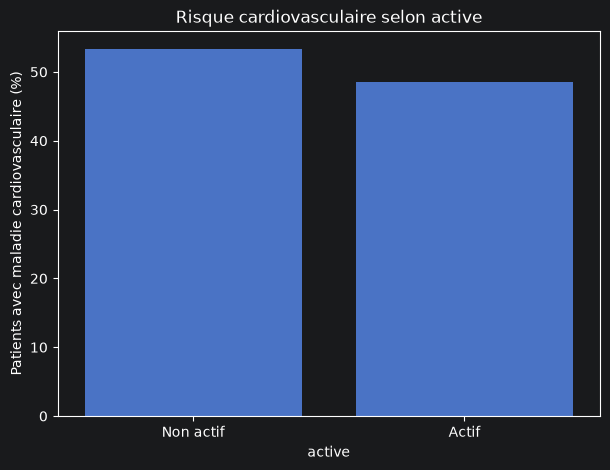

      active     cardio
0  Non actif  53.272067
1      Actif  48.542086

Chi² : 96.823
p-value : 0.00000
✅ Association statistiquement significative


In [11]:
dp.analyse_categorical(
    df,
    "active",
    {
        0:"Non actif",
        1:"Actif"
    }
)

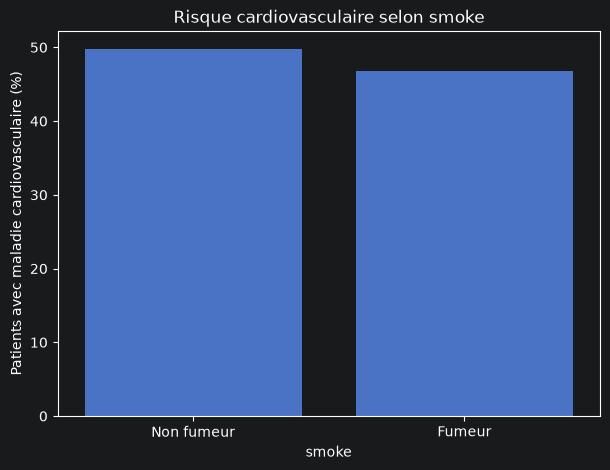

        smoke     cardio
0  Non fumeur  49.724313
1      Fumeur  46.859983

Chi² : 17.951
p-value : 0.00002
✅ Association statistiquement significative


In [12]:
analyse_categorical(
    df,
    "smoke",
    {
        0:"Non fumeur",
        1:"Fumeur"
    }
)

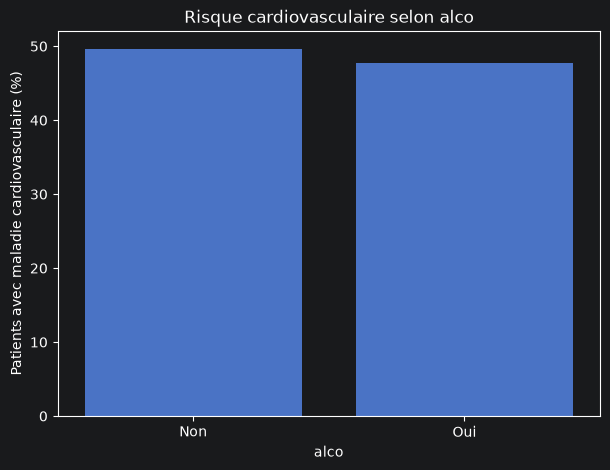

  alco     cardio
0  Non  49.572729
1  Oui  47.690626

Chi² : 4.834
p-value : 0.02791
✅ Association statistiquement significative


In [13]:
analyse_categorical(
    df,
    "alco",
    {
        0:"Non",
        1:"Oui"
    }
)

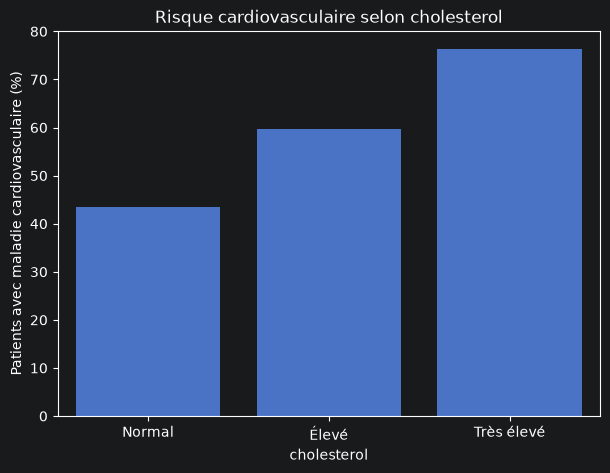

  cholesterol     cardio
0      Normal  43.541646
1       Élevé  59.634212
2  Très élevé  76.252225

Chi² : 3364.581
p-value : 0.00000
✅ Association statistiquement significative


In [14]:
analyse_categorical(
    df,
    "cholesterol",
    {
        1:"Normal",
        2:"Élevé",
        3:"Très élevé"
    }
)

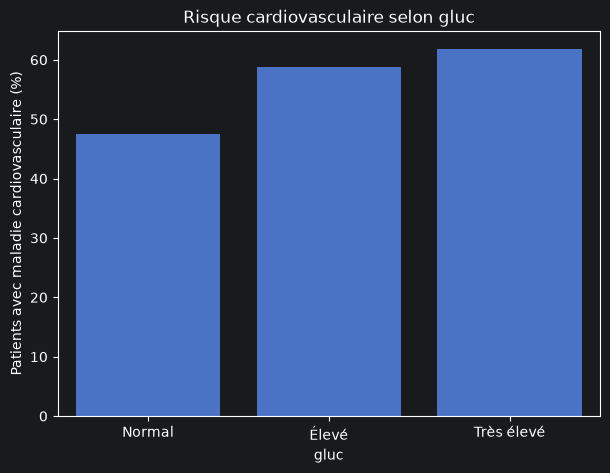

         gluc     cardio
0      Normal  47.559449
1       Élevé  58.863008
2  Très élevé  61.749472

Chi² : 578.431
p-value : 0.00000
✅ Association statistiquement significative


In [15]:
analyse_categorical(
    df,
    "gluc",
    {
        1:"Normal",
        2:"Élevé",
        3:"Très élevé"
    }
)

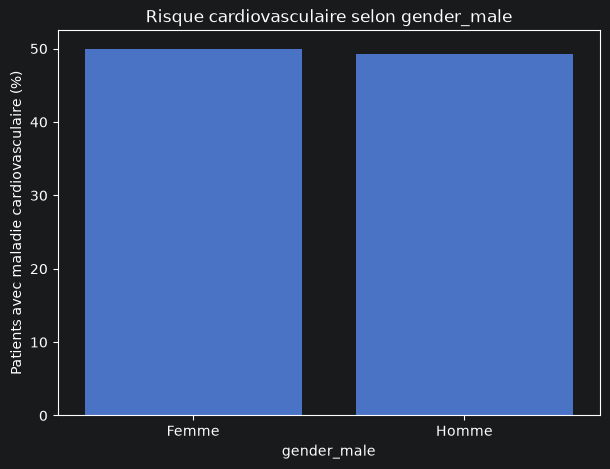

  gender_male     cardio
0       Femme  49.970738
1       Homme  49.205532

Chi² : 3.619
p-value : 0.05712
❌ Pas d'association statistiquement significative


In [16]:
analyse_categorical(
    df,
    "gender_male",
    {
        0:"Femme",
        1:"Homme"
    }
)

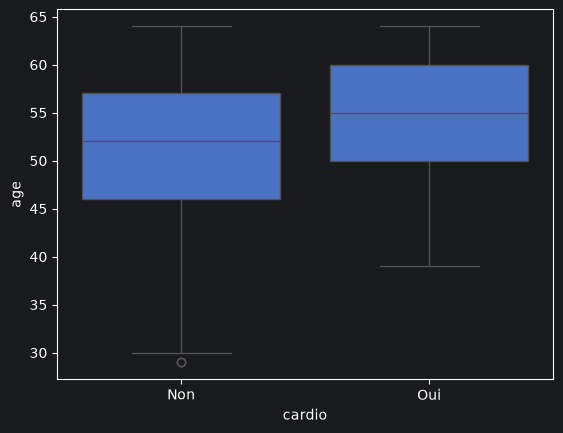

cardio
0    51.225155
1    54.466073
Name: age, dtype: float64

p-value : 0.0000000000
✅ Association statistiquement significative


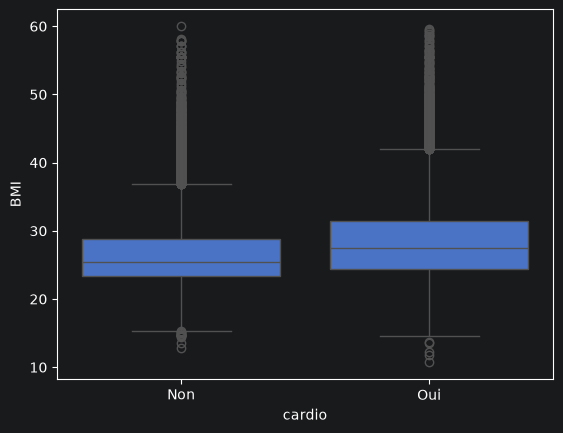

cardio
0    26.462901
1    28.454461
Name: BMI, dtype: float64

p-value : 0.0000000000
✅ Association statistiquement significative


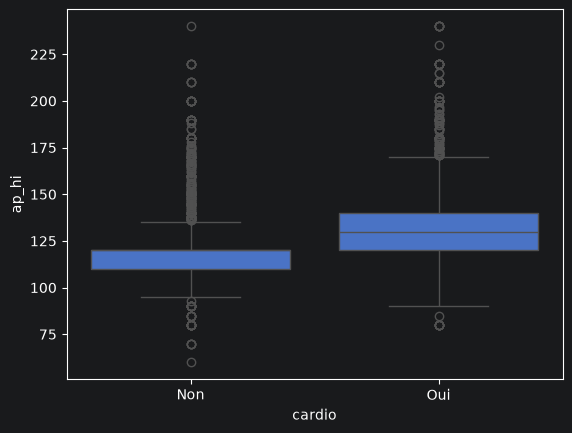

cardio
0    119.602625
1    133.890162
Name: ap_hi, dtype: float64

p-value : 0.0000000000
✅ Association statistiquement significative


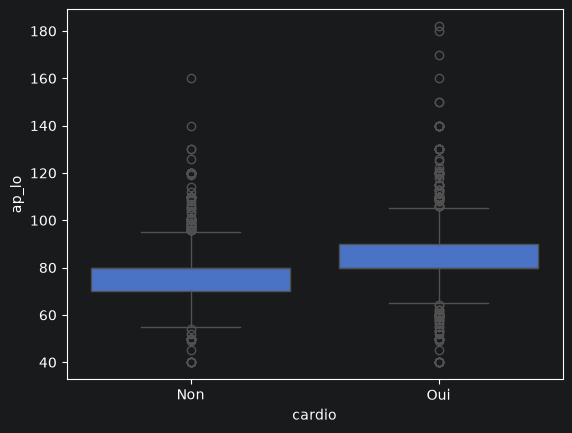

cardio
0    78.124621
1    84.554757
Name: ap_lo, dtype: float64

p-value : 0.0000000000
✅ Association statistiquement significative


In [17]:
dp.analyse_numeric(df,"age")
dp.analyse_numeric(df,"BMI")
dp.analyse_numeric(df,"ap_hi")
dp.analyse_numeric(df,"ap_lo")

In [18]:
bins = [30, 40, 50, 60, 70]

labels = [
    "30-39",
    "40-49",
    "50-59",
    "60-69"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels,
    right=False
)

In [19]:
risk_age = (
    df
    .groupby("age_group")["cardio"]
    .mean()
    * 100
).reset_index()

risk_age

,age_group,cardio
0,30-39,23.961298
1,40-49,37.452659
2,50-59,51.093234
3,60-69,66.724111


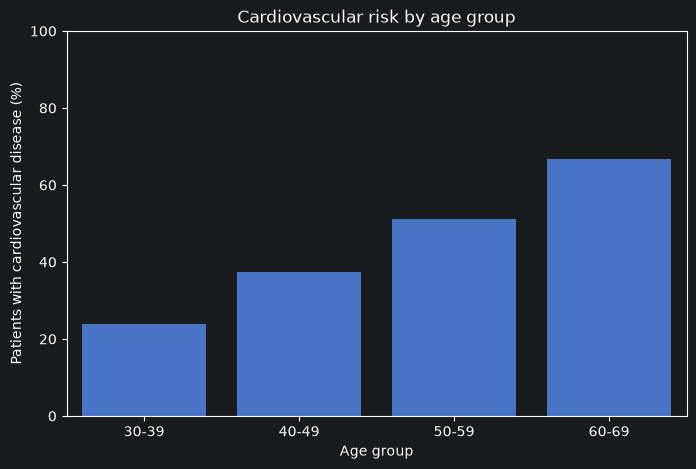

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=risk_age,
    x="age_group",
    y="cardio"
)

plt.title("Cardiovascular risk by age group")
plt.xlabel("Age group")
plt.ylabel("Patients with cardiovascular disease (%)")

plt.ylim(0,100)

plt.show()

In [21]:
table = pd.crosstab(
    df["age_group"],
    df["cardio"]
)

chi2, p, dof, expected = chi2_contingency(table)

print(table)

print(f"\nChi² : {chi2:.2f}")
print(f"p-value : {p:.5f}")

cardio         0      1
age_group              
30-39       1336    421
40-49      12056   7219
50-59      17022  17783
60-69       4248   8518

Chi² : 3127.98
p-value : 0.00000
